In [9]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt



root_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils").exists()), None)
if root_path is None:
    raise FileNotFoundError("Could not locate project root containing 'utils' directory")
sys.path.append(str(root_path))

from utils.helpers import load_data

In [10]:
df = load_data("../data/CBM_format/IN1020_2025konte_CBM.csv")
df.head()

Data loaded successfully from ../data/CBM_format/IN1020_2025konte_CBM.csv


,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,auto_score,svaralternativ,sikkerhetsgrad
0,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,1,5
1,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,4,1
2,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,3,1
3,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,5,1
4,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,2,1


### Plot total auto score

Number of unique students: 68


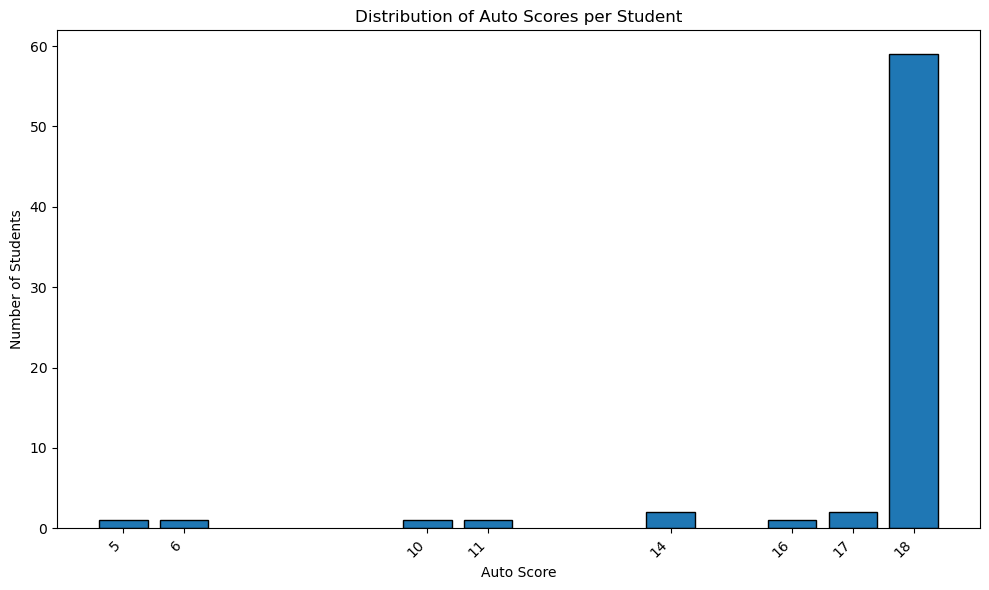

In [17]:
student_scores = df.drop_duplicates(subset=["student_id"])[["student_id", "auto_score"]]

print(f"Number of unique students: {len(student_scores)}")

#By using value_counts().sort_index(), each bar is drawn at the exact score value that students actually received
score_counts = student_scores["auto_score"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(score_counts.index, score_counts.values, width=0.8, edgecolor="black", align="center")
plt.xticks(score_counts.index, rotation=45, ha="right")
plt.xlabel("Auto Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Auto Scores per Student")
plt.tight_layout()
plt.show()
